In [ ]:
!pip install openpyxl


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Online Sales Data.csv.xlsx to Online Sales Data.csv.xlsx


In [ ]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [ ]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (240, 9)


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Transaction ID', 'Date', 'Product Category', 'Product Name', 'Units Sold', 'Unit Price', 'Total Revenue', 'Region', 'Payment Method']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    240 non-null    int64         
 1   Date              240 non-null    datetime64[ns]
 2   Product Category  240 non-null    object        
 3   Product Name      240 non-null    object        
 4   Units Sold        240 non-null    int64         
 5   Unit Price        240 non-null    float64       
 6   Total Revenue     240 non-null    float64       
 7   Region            240 non-null    object        
 8   Payment Method    240 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 17.0+ KB


In [ ]:
df.describe()

,Transaction ID,Date,Units Sold,Unit Price,Total Revenue
count,240.00000,240,240.000000,240.000000,240.000000
mean,10120.50000,2024-04-29 12:00:00,2.158333,236.395583,335.699375
min,10001.00000,2024-01-01 00:00:00,1.000000,6.500000,6.500000
25%,10060.75000,2024-02-29 18:00:00,1.000000,29.500000,62.965000
50%,10120.50000,2024-04-29 12:00:00,2.000000,89.990000,179.970000
75%,10180.25000,2024-06-28 06:00:00,3.000000,249.990000,399.225000
max,10240.00000,2024-08-27 00:00:00,10.000000,3899.990000,3899.990000
std,69.42622,NaN,1.322454,429.446695,485.804469


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Product Category,0
Product Name,0
Units Sold,0
Unit Price,0
Total Revenue,0
Region,0
Payment Method,0


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Total Revenue'])

plt.title('Box Plot of Total Revenue')
plt.xlabel('Total Revenue')

plt.show()

NameError: name 'plt' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

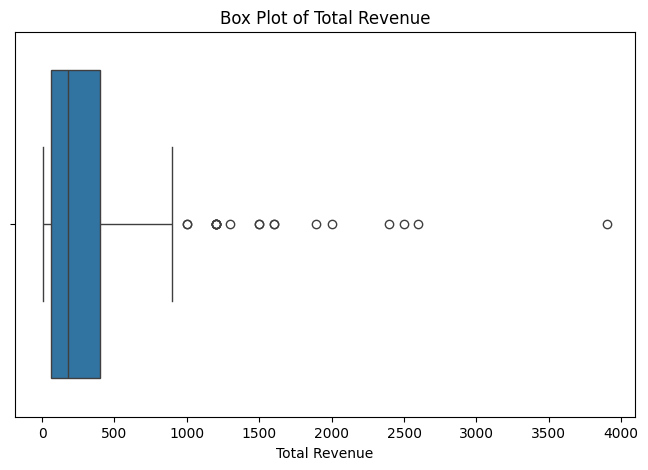

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Total Revenue'])

plt.title('Box Plot of Total Revenue')
plt.xlabel('Total Revenue')

plt.show()

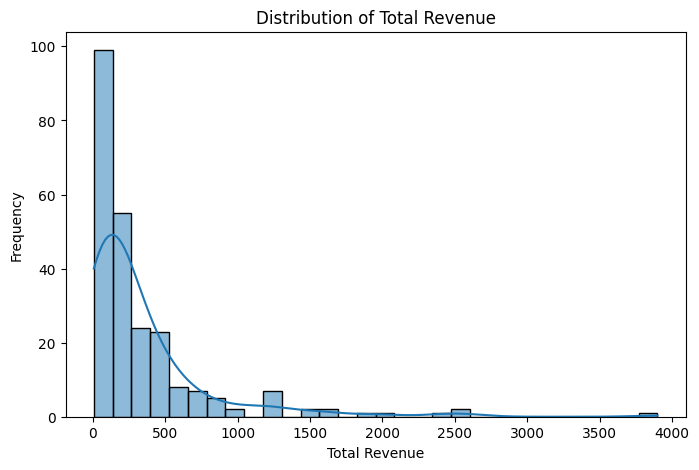

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total Revenue'], bins=30, kde=True)

plt.title('Distribution of Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# Statistical summary of Total Revenue
df['Total Revenue'].describe()

,Total Revenue
count,240.000000
mean,335.699375
std,485.804469
min,6.500000
25%,62.965000
50%,179.970000
75%,399.225000
max,3899.990000


In [ ]:
# Calculate Q1 and Q3
Q1 = df['Total Revenue'].quantile(0.25)
Q3 = df['Total Revenue'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 62.965
Q3: 399.225
IQR: 336.26
Lower Bound: -441.42499999999995
Upper Bound: 903.615


In [ ]:
# Identify outliers
outliers = df[
    (df['Total Revenue'] < lower_bound) |
    (df['Total Revenue'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("\nOutlier values:")
print(outliers['Total Revenue'].sort_values().to_list())

Number of outliers: 19

Outlier values:
[999.98, 999.99, 1199.97, 1199.97, 1199.98, 1199.98, 1199.99, 1199.99, 1299.99, 1499.98, 1499.99, 1599.98, 1599.99, 1895.0, 1999.98, 2399.0, 2499.99, 2599.98, 3899.99]


In [ ]:
# Display all outlier records
outliers

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
6,10007,2024-01-07,Electronics,MacBook Pro 16-inch,1,2499.99,2499.99,North America,Credit Card
7,10008,2024-01-08,Home Appliances,Blueair Classic 480i,2,599.99,1199.98,Europe,PayPal
12,10013,2024-01-13,Electronics,Samsung Galaxy Tab S8,2,749.99,1499.98,North America,Credit Card
18,10019,2024-01-19,Electronics,Garmin Forerunner 945,2,499.99,999.98,North America,Credit Card
35,10036,2024-02-05,Sports,Peloton Bike,1,1895.00,1895.00,Asia,Credit Card
36,10037,2024-02-06,Electronics,Apple Watch Series 8,3,399.99,1199.97,North America,Credit Card
37,10038,2024-02-07,Home Appliances,Roomba i7+,2,799.99,1599.98,Europe,PayPal
42,10043,2024-02-12,Electronics,GoPro HERO10 Black,3,399.99,1199.97,North America,Credit Card
66,10067,2024-03-07,Electronics,Samsung QLED 4K TV,1,1199.99,1199.99,North America,Credit Card


In [ ]:
pd.set_option('display.max_columns', None)

outliers

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
6,10007,2024-01-07,Electronics,MacBook Pro 16-inch,1,2499.99,2499.99,North America,Credit Card
7,10008,2024-01-08,Home Appliances,Blueair Classic 480i,2,599.99,1199.98,Europe,PayPal
12,10013,2024-01-13,Electronics,Samsung Galaxy Tab S8,2,749.99,1499.98,North America,Credit Card
18,10019,2024-01-19,Electronics,Garmin Forerunner 945,2,499.99,999.98,North America,Credit Card
35,10036,2024-02-05,Sports,Peloton Bike,1,1895.00,1895.00,Asia,Credit Card
36,10037,2024-02-06,Electronics,Apple Watch Series 8,3,399.99,1199.97,North America,Credit Card
37,10038,2024-02-07,Home Appliances,Roomba i7+,2,799.99,1599.98,Europe,PayPal
42,10043,2024-02-12,Electronics,GoPro HERO10 Black,3,399.99,1199.97,North America,Credit Card
66,10067,2024-03-07,Electronics,Samsung QLED 4K TV,1,1199.99,1199.99,North America,Credit Card


In [ ]:
# Summary of the outlier revenue values
outliers['Total Revenue'].describe()

,Total Revenue
count,19.000000
mean,1683.880000
std,731.883748
min,999.980000
25%,1199.980000
50%,1499.980000
75%,1947.490000
max,3899.990000


In [ ]:
# Show the highest revenue transactions
outliers.sort_values('Total Revenue', ascending=False)

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
102,10103,2024-04-12,Electronics,Canon EOS R5 Camera,1,3899.99,3899.99,North America,Credit Card
85,10086,2024-03-26,Home Appliances,LG OLED TV,2,1299.99,2599.98,Europe,PayPal
6,10007,2024-01-07,Electronics,MacBook Pro 16-inch,1,2499.99,2499.99,North America,Credit Card
216,10217,2024-08-04,Electronics,Apple MacBook Pro 16-inch,1,2399.00,2399.00,North America,Credit Card
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
35,10036,2024-02-05,Sports,Peloton Bike,1,1895.00,1895.00,Asia,Credit Card
72,10073,2024-03-13,Electronics,HP Spectre x360 Laptop,1,1599.99,1599.99,North America,Credit Card
37,10038,2024-02-07,Home Appliances,Roomba i7+,2,799.99,1599.98,Europe,PayPal
138,10139,2024-05-18,Electronics,Samsung Odyssey G9 Gaming Monitor,1,1499.99,1499.99,North America,Credit Card
12,10013,2024-01-13,Electronics,Samsung Galaxy Tab S8,2,749.99,1499.98,North America,Credit Card


In [ ]:
# Flag revenue outliers instead of deleting them
df['Revenue_Outlier'] = (
    (df['Total Revenue'] < lower_bound) |
    (df['Total Revenue'] > upper_bound)
)

print("Outliers flagged:", df['Revenue_Outlier'].sum())
print("Normal records:", (~df['Revenue_Outlier']).sum())

Outliers flagged: 19
Normal records: 221


In [ ]:
df[df['Revenue_Outlier']][
    ['Transaction ID', 'Product Name', 'Units Sold',
     'Unit Price', 'Total Revenue', 'Region']
].sort_values('Total Revenue', ascending=False)

,Transaction ID,Product Name,Units Sold,Unit Price,Total Revenue,Region
102,10103,Canon EOS R5 Camera,1,3899.99,3899.99,North America
85,10086,LG OLED TV,2,1299.99,2599.98,Europe
6,10007,MacBook Pro 16-inch,1,2499.99,2499.99,North America
216,10217,Apple MacBook Pro 16-inch,1,2399.00,2399.00,North America
0,10001,iPhone 14 Pro,2,999.99,1999.98,North America
35,10036,Peloton Bike,1,1895.00,1895.00,Asia
72,10073,HP Spectre x360 Laptop,1,1599.99,1599.99,North America
37,10038,Roomba i7+,2,799.99,1599.98,Europe
138,10139,Samsung Odyssey G9 Gaming Monitor,1,1499.99,1499.99,North America
12,10013,Samsung Galaxy Tab S8,2,749.99,1499.98,North America


In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


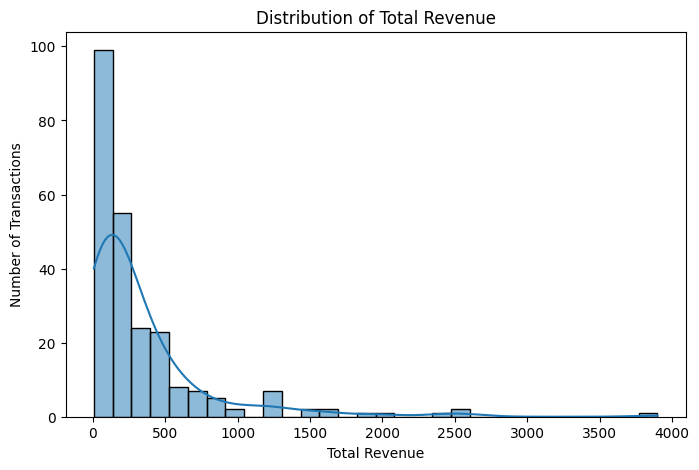

In [ ]:
# Distribution of Total Revenue

plt.figure(figsize=(8, 5))

sns.histplot(df['Total Revenue'], bins=30, kde=True)

plt.title('Distribution of Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Number of Transactions')

plt.show()

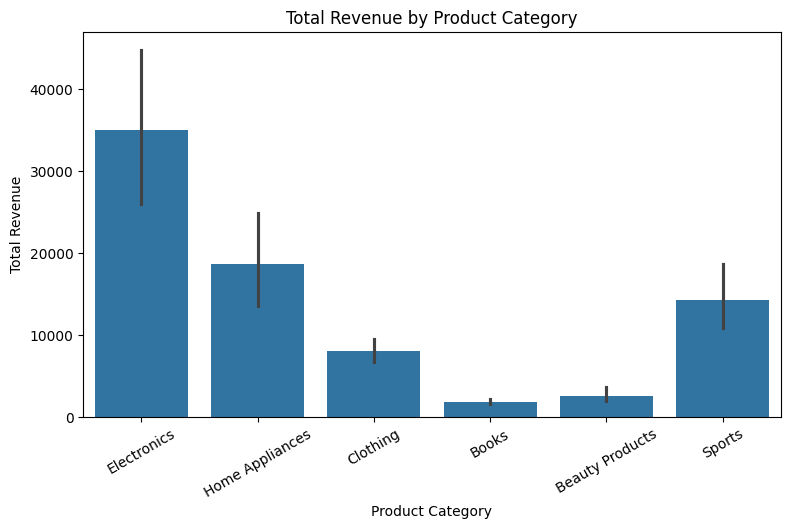

In [ ]:
# Revenue by Product Category

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Product Category',
    y='Total Revenue',
    estimator='sum'
)

plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=30)
plt.show()

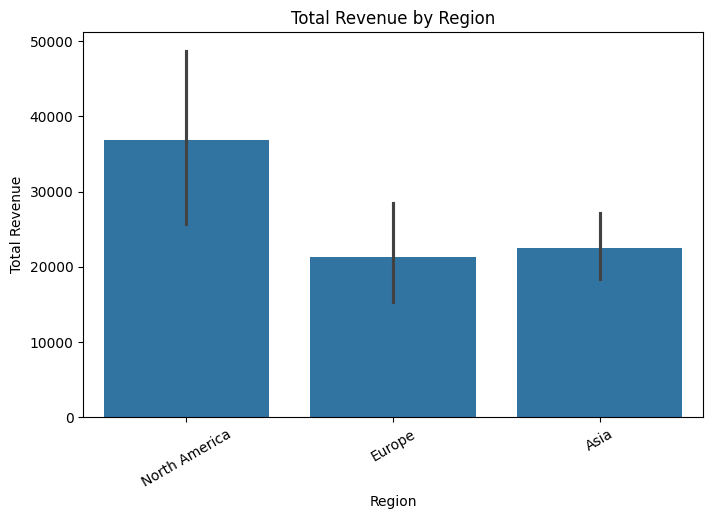

In [ ]:
# Total Revenue by Region

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Region',
    y='Total Revenue',
    estimator='sum'
)

plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')

plt.xticks(rotation=30)
plt.show()

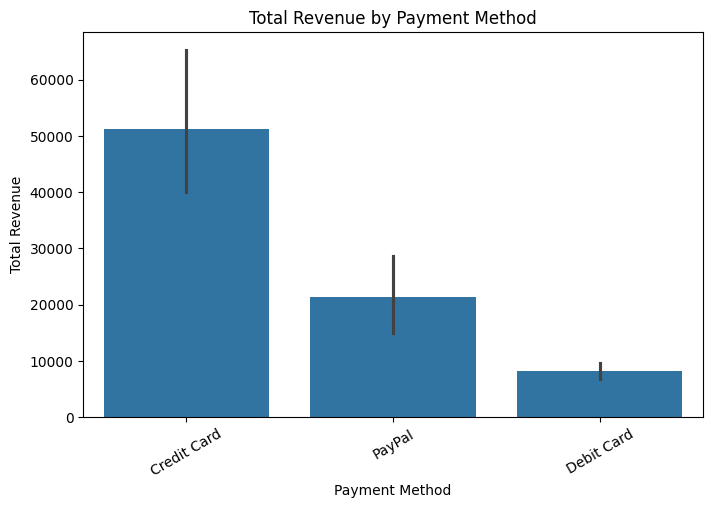

In [ ]:
# Total Revenue by Payment Method

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Payment Method',
    y='Total Revenue',
    estimator='sum'
)

plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')

plt.xticks(rotation=30)
plt.show()

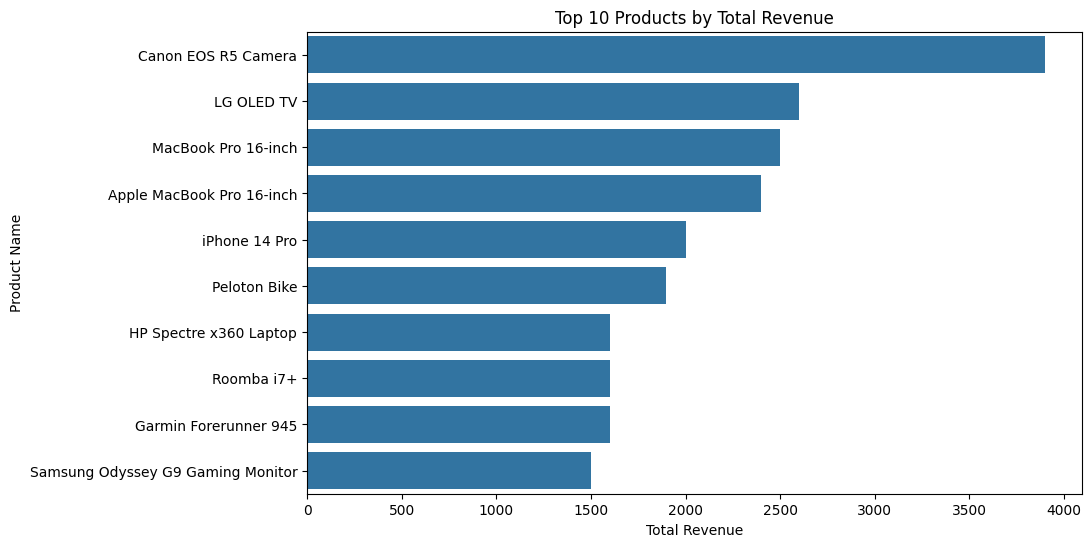

In [ ]:
# Top 10 Products by Total Revenue

top_products = (
    df.groupby('Product Name')['Total Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')

plt.show()

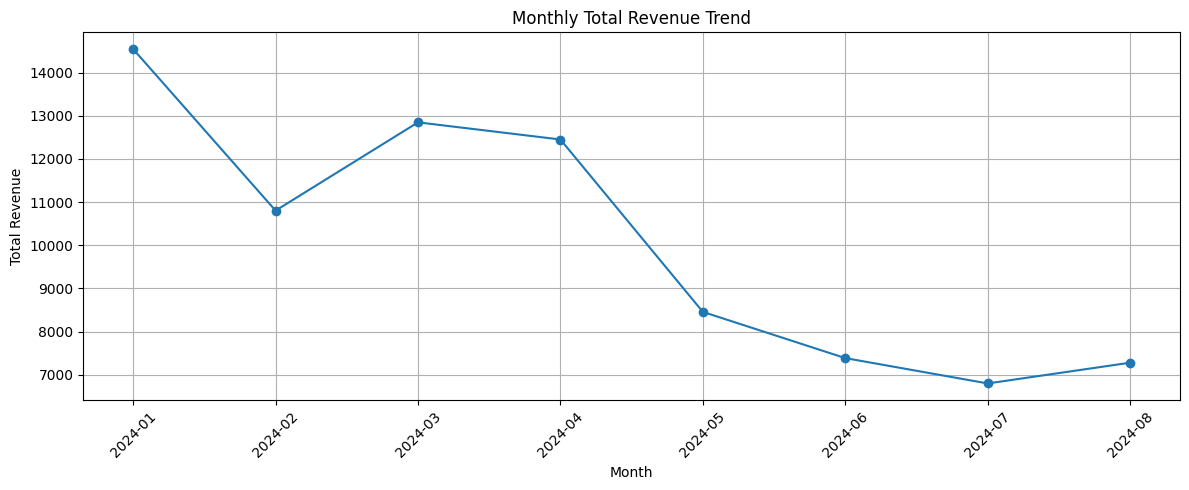

In [ ]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Calculate monthly revenue
monthly_revenue = (
    df.groupby(df['Date'].dt.to_period('M'))['Total Revenue']
      .sum()
)

# Convert period to string for plotting
monthly_revenue.index = monthly_revenue.index.astype(str)

# Plot monthly revenue
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o'
)

plt.title('Monthly Total Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
# Check all unique product names

print("Number of unique products:", df['Product Name'].nunique())

print("\nProduct names:")
print(sorted(df['Product Name'].unique()))

Number of unique products: 232

Product names:
['1984 by George Orwell', 'Adidas 3-Stripes Shorts', 'Adidas Essential Track Pants', 'Adidas FIFA World Cup Football', 'Adidas Originals Superstar Sneakers', 'Adidas Originals Trefoil Hoodie', 'Adidas Ultraboost Running Shoes', 'Adidas Ultraboost Shoes', 'Amazon Echo Dot (4th Gen)', 'Amazon Echo Show 10', 'Amazon Fire TV Stick 4K', 'Anastasia Beverly Hills Brow Wiz', 'Anker PowerCore Portable Charger', 'Anova Precision Cooker', 'Anova Precision Oven', 'Apple AirPods Max', 'Apple AirPods Pro', 'Apple MacBook Air', 'Apple MacBook Pro 16-inch', 'Apple TV 4K', 'Apple Watch Series 8', 'Apple iPad Air', 'Atomic Habits by James Clear', 'Babolat Pure Drive Tennis Racket', 'Becoming by Michelle Obama', 'Biore UV Aqua Rich Watery Essence Sunscreen', 'Blueair Classic 480i', 'Bose QuietComfort 35 Headphones', 'Bose QuietComfort 35 II Wireless Headphones', 'Bose SoundLink Color Bluetooth Speaker II', 'Bose SoundLink Revolve+ Speaker', 'Bose SoundSport 

In [ ]:
# Check product names containing "MacBook"

macbook_products = [
    name for name in df['Product Name'].unique()
    if 'MacBook' in name
]

print("MacBook product names:")
for product in sorted(macbook_products):
    print(product)

MacBook product names:
Apple MacBook Air
Apple MacBook Pro 16-inch
MacBook Pro 16-inch


In [ ]:
# Find product names that appear more than once

product_counts = df['Product Name'].value_counts()

print("Repeated product names:")
print(product_counts[product_counts > 1])

Repeated product names:
Product Name
Dyson Supersonic Hair Dryer                         2
Garmin Forerunner 945                               2
Keurig K-Elite Coffee Maker                         2
Sony WH-1000XM4 Headphones                          2
Dune by Frank Herbert                               2
The Silent Patient by Alex Michaelides              2
The Catcher in the Rye by J.D. Salinger             2
The Girl with the Dragon Tattoo by Stieg Larsson    2
Name: count, dtype: int64


In [ ]:
# Final check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
Revenue_Outlier     0
dtype: int64

Total missing values: 0


In [ ]:
# Final dataset information

print("Rows and columns:", df.shape)
print("\nData types:")
print(df.dtypes)

Rows and columns: (240, 10)

Data types:
Transaction ID               int64
Date                datetime64[ns]
Product Category            object
Product Name                object
Units Sold                   int64
Unit Price                 float64
Total Revenue              float64
Region                      object
Payment Method              object
Revenue_Outlier               bool
dtype: object


In [ ]:
print("========== FINAL BUSINESS INSIGHTS ==========")

# Best category
category_sales = df.groupby('Product Category')['Total Revenue'].sum()
print("1. Highest revenue category:", category_sales.idxmax(),
      "→", round(category_sales.max(), 2))

# Best region
region_sales = df.groupby('Region')['Total Revenue'].sum()
print("2. Highest revenue region:", region_sales.idxmax(),
      "→", round(region_sales.max(), 2))

# Best payment method
payment_sales = df.groupby('Payment Method')['Total Revenue'].sum()
print("3. Most revenue-generating payment method:", payment_sales.idxmax(),
      "→", round(payment_sales.max(), 2))

# Best product
product_sales = df.groupby('Product Name')['Total Revenue'].sum()
print("4. Top product:", product_sales.idxmax(),
      "→", round(product_sales.max(), 2))

# Best month
monthly_sales = df.groupby('Month')['Total Revenue'].sum()
print("5. Highest revenue month:", monthly_sales.idxmax(),
      "→", round(monthly_sales.max(), 2))

print("6. Number of unique products:", df['Product Name'].nunique())
print("7. Number of outliers:", len(outliers))

========== FINAL BUSINESS INSIGHTS ==========
1. Highest revenue category: Electronics → 34982.41
2. Highest revenue region: North America → 36844.34
3. Most revenue-generating payment method: Credit Card → 51170.86
4. Top product: Canon EOS R5 Camera → 3899.99


KeyError: 'Month'

               Units Sold  Unit Price  Total Revenue
Units Sold       1.000000   -0.308583      -0.171151
Unit Price      -0.308583    1.000000       0.930350
Total Revenue   -0.171151    0.930350       1.000000


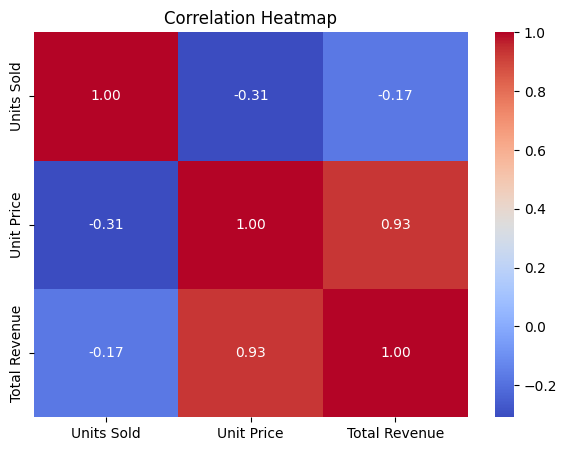

In [ ]:
# Correlation between numerical variables

numeric_cols = ['Units Sold', 'Unit Price', 'Total Revenue']

correlation = df[numeric_cols].corr()

print(correlation)

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

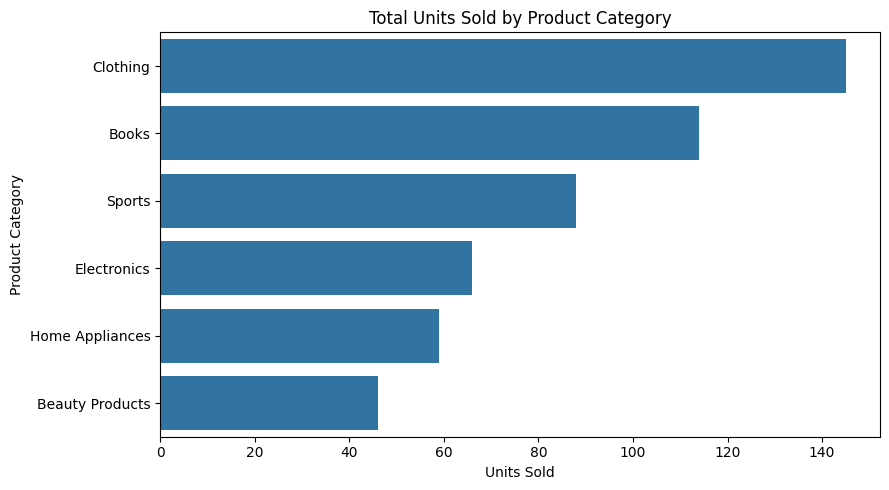

In [ ]:
# Total Units Sold by Product Category

category_units = df.groupby('Product Category')['Units Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=category_units.values,
    y=category_units.index
)

plt.title('Total Units Sold by Product Category')
plt.xlabel('Units Sold')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [ ]:
# Final KPI Summary

total_revenue = df['Total Revenue'].sum()
total_units = df['Units Sold'].sum()
avg_revenue = df['Total Revenue'].mean()
total_transactions = df['Transaction ID'].nunique()

print("========== FINAL KPI SUMMARY ==========")
print("Total Revenue:", round(total_revenue, 2))
print("Total Units Sold:", total_units)
print("Average Revenue per Transaction:", round(avg_revenue, 2))
print("Total Transactions:", total_transactions)
print("Unique Products:", df['Product Name'].nunique())
print("Revenue Outliers:", df['Revenue_Outlier'].sum())

========== FINAL KPI SUMMARY ==========
Total Revenue: 80567.85
Total Units Sold: 518
Average Revenue per Transaction: 335.7
Total Transactions: 240
Unique Products: 232
Revenue Outliers: 19


In [ ]:
# Key Business Insights

print("========== KEY BUSINESS INSIGHTS ==========")

category_sales = df.groupby('Product Category')['Total Revenue'].sum()
region_sales = df.groupby('Region')['Total Revenue'].sum()
payment_sales = df.groupby('Payment Method')['Total Revenue'].sum()
product_sales = df.groupby('Product Name')['Total Revenue'].sum()

print("1. Top Product Category:", category_sales.idxmax())
print("2. Top Region:", region_sales.idxmax())
print("3. Top Payment Method:", payment_sales.idxmax())
print("4. Top Product:", product_sales.idxmax())
print("5. Number of Revenue Outliers:", df['Revenue_Outlier'].sum())

========== KEY BUSINESS INSIGHTS ==========
1. Top Product Category: Electronics
2. Top Region: North America
3. Top Payment Method: Credit Card
4. Top Product: Canon EOS R5 Camera
5. Number of Revenue Outliers: 19


## Conclusion

The Online Sales Data Analysis project successfully analyzed and visualized sales data using Python. The dataset was examined for missing values, duplicate records, outliers, and data consistency.

Exploratory Data Analysis using Pandas, Matplotlib, and Seaborn helped identify important patterns in revenue, product categories, regions, payment methods, top-performing products, and monthly sales trends.

The analysis provides useful business insights that can support better inventory management, marketing strategies, product planning, and regional sales decisions. Overall, the project demonstrates how data cleaning, visualization, and analysis can be used to transform raw sales data into meaningful business insights.

          ONLINE SALES ANALYTICS DASHBOARD
Total Revenue       : 80,567.85
Total Units Sold    : 518
Total Transactions  : 240
Top Product Category: Electronics


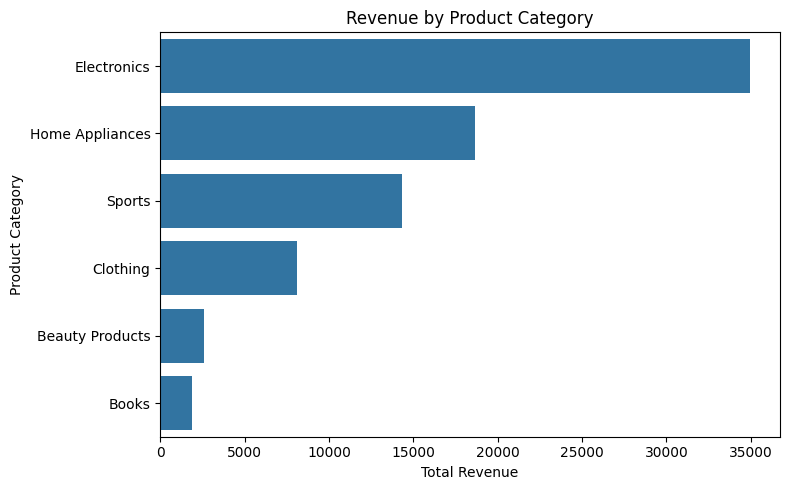

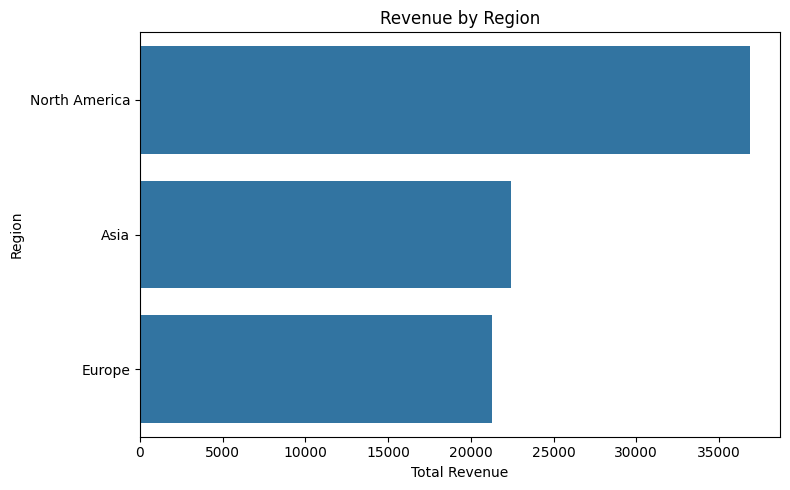

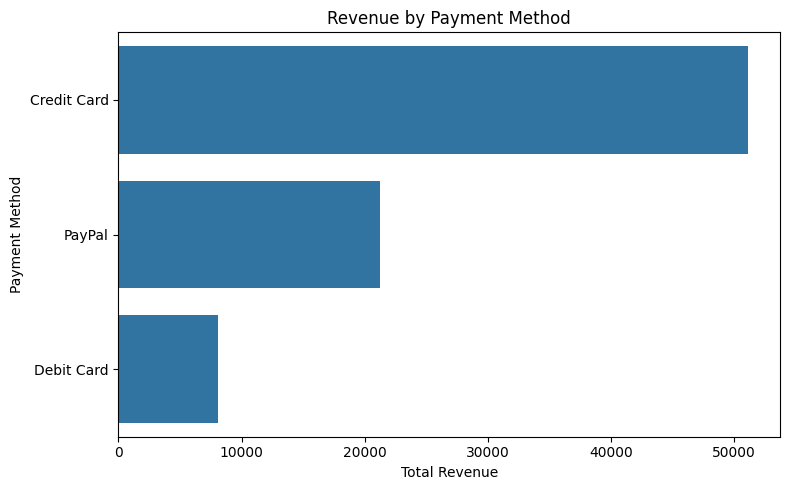

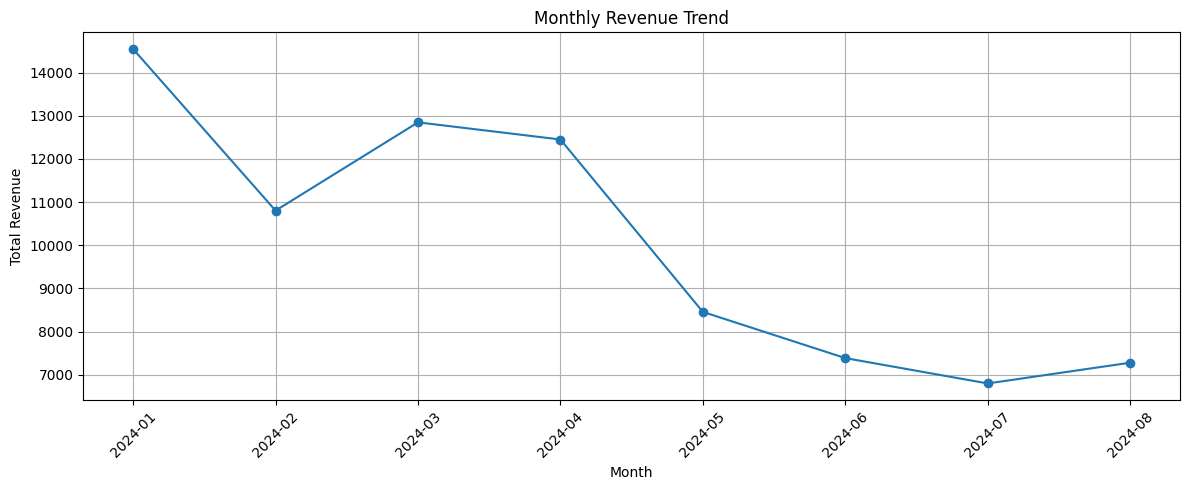

In [ ]:
# ==============================
# SALES ANALYTICS DASHBOARD
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# KPI calculations
total_revenue = df['Total Revenue'].sum()
total_units = df['Units Sold'].sum()
total_transactions = df['Transaction ID'].nunique()
top_category = df.groupby('Product Category')['Total Revenue'].sum().idxmax()

print("=" * 50)
print("          ONLINE SALES ANALYTICS DASHBOARD")
print("=" * 50)

print(f"Total Revenue       : {total_revenue:,.2f}")
print(f"Total Units Sold    : {total_units:,}")
print(f"Total Transactions  : {total_transactions:,}")
print(f"Top Product Category: {top_category}")

print("=" * 50)

# 1. Revenue by Category
plt.figure(figsize=(8, 5))
category_revenue = df.groupby('Product Category')['Total Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.values, y=category_revenue.index)
plt.title('Revenue by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

# 2. Revenue by Region
plt.figure(figsize=(8, 5))
region_revenue = df.groupby('Region')['Total Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=region_revenue.values, y=region_revenue.index)
plt.title('Revenue by Region')
plt.xlabel('Total Revenue')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

# 3. Revenue by Payment Method
plt.figure(figsize=(8, 5))
payment_revenue = df.groupby('Payment Method')['Total Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=payment_revenue.values, y=payment_revenue.index)
plt.title('Revenue by Payment Method')
plt.xlabel('Total Revenue')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()

# 4. Monthly Revenue Trend
plt.figure(figsize=(12, 5))
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Total Revenue'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save the cleaned dataset

df.to_csv('cleaned_online_sales_data.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
